# Assignment 1
**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, RNNs, Transformers, Huggingface



# Contact
For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

- Federico Ruggeri -> federico.ruggeri6@unibo.it
- Eleonora Mancini -> e.mancini@unibo.it

Professor:
- Paolo Torroni -> p.torroni@unibo.it

# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [1]:
!pip install nltk tqdm gensim gdown emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 41.4 MB/s eta 0:00:00


In [60]:
# data and numerical management packages
import pandas as pd
import numpy as np
import simplejson as sj

# system packages
from pathlib import Path
import shutil
import urllib
import tarfile
import zipfile
import sys
import gc
import time
import requests
import gdown

# typing
from typing import List, Callable, Dict, Tuple
from collections import Counter, OrderedDict

# pre-processing
import re
import nltk
from nltk.corpus import stopwords

# embeddings
import gensim
import gensim.downloader as gloader

# visualization
import matplotlib.pyplot as plt
import umap

# utility
import json
from functools import reduce
from itertools import product

# useful during debugging (progress bars)
from tqdm import tqdm

import warnings
import codecs
import emoji

import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.tokenize import WhitespaceTokenizer

import umap
import torch
import torch.nn as nn

In [3]:
data_path = "https://drive.google.com/drive/folders/1l2mbz9ptBQcnHb1OK1D9OxFp3utxlx6v?usp=drive_link"

In [4]:
test_path, train_path, val_path = gdown.download_folder(data_path, quiet=False, use_cookies=False)

Retrieving folder contents


Processing file 1iHRg8UJ795as8iy398VFV_hDoPRE1njX test.json
Processing file 1RGmmJW3oE8o4_lu9DKunYNOFDvcgYEkz training.json
Processing file 1ihNtzeFVjvZRCRUvL4QY0l_89a2EltAG validation.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1iHRg8UJ795as8iy398VFV_hDoPRE1njX
To: /content/data/test.json
100%|██████████| 492k/492k [00:00<00:00, 117MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RGmmJW3oE8o4_lu9DKunYNOFDvcgYEkz
To: /content/data/training.json
100%|██████████| 6.22M/6.22M [00:00<00:00, 37.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ihNtzeFVjvZRCRUvL4QY0l_89a2EltAG
To: /content/data/validation.json
100%|██████████| 1.16M/1.16M [00:00<00:00, 52.5MB/s]
Download completed


In [5]:
train_df = pd.read_json(train_path, orient="index")
val_df = pd.read_json(val_path, orient="index")
test_df = pd.read_json(test_path, orient="index")

In [6]:
print("Training dataset shape:", train_df.shape)
print("Validation dataset shape:", val_df.shape)
print("Test dataset shape:", test_df.shape)

Training dataset shape: (6920, 11)
Validation dataset shape: (726, 11)
Test dataset shape: (312, 11)


In [7]:
train_df.iloc[0].to_dict()

{'id_EXIST': 100001,
 'lang': 'es',
 'tweet': '@TheChiflis Ignora al otro, es un capullo.El problema con este youtuber denuncia el acoso... cuando no afecta a la gente de izquierdas. Por ejemplo, en su video sobre el gamergate presenta como "normal" el acoso que reciben Fisher, Anita o Zöey cuando hubo hasta amenazas de bomba.',
 'number_annotators': 6,
 'annotators': ['Annotator_1',
  'Annotator_2',
  'Annotator_3',
  'Annotator_4',
  'Annotator_5',
  'Annotator_6'],
 'gender_annotators': ['F', 'F', 'F', 'M', 'M', 'M'],
 'age_annotators': ['18-22', '23-45', '46+', '46+', '23-45', '18-22'],
 'labels_task1': ['YES', 'YES', 'NO', 'YES', 'YES', 'YES'],
 'labels_task2': ['REPORTED',
  'JUDGEMENTAL',
  '-',
  'REPORTED',
  'JUDGEMENTAL',
  'REPORTED'],
 'labels_task3': [['OBJECTIFICATION'],
  ['OBJECTIFICATION', 'SEXUAL-VIOLENCE'],
  ['-'],
  ['STEREOTYPING-DOMINANCE'],
  ['SEXUAL-VIOLENCE'],
  ['IDEOLOGICAL-INEQUALITY', 'MISOGYNY-NON-SEXUAL-VIOLENCE']],
 'split': 'TRAIN_ES'}

In [8]:
train_df.columns

Index(['id_EXIST', 'lang', 'tweet', 'number_annotators', 'annotators',
       'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2',
       'labels_task3', 'split'],
      dtype='object')

In [9]:
def majority_vote(labels):
    #count frequencies
    counts = Counter(labels)
    #order lables from most to less frequent like [('DIRECT',2), ('REPORTED',2), ('JUDGEMENTAL',1)] and take just the first two
    most_common = counts.most_common(2)

    if len(most_common) == 0 or (len(most_common) > 1 and most_common[0][1] == most_common[1][1]):
        return np.nan

    else:
      return most_common[0][0]

In [10]:
train_df["label"] = train_df["labels_task2"].apply(majority_vote)
val_df["label"] = val_df["labels_task2"].apply(majority_vote)
test_df["label"] = test_df["labels_task2"].apply(majority_vote)

train_df = train_df.dropna(subset=["label"])
val_df = val_df.dropna(subset=["label"])
test_df = test_df.dropna(subset=["label"])

In [11]:
train_df[["labels_task2", "label"]].head()

,labels_task2,label
100001,"[REPORTED, JUDGEMENTAL, -, REPORTED, JUDGEMENT...",REPORTED
100002,"[-, -, -, -, DIRECT, -]",-
100003,"[-, -, -, -, -, -]",-
100004,"[-, -, DIRECT, -, REPORTED, REPORTED]",-
100006,"[-, -, -, -, -, -]",-


In [12]:
train_df["label"].value_counts()

,count
label,
-,3987
DIRECT,1275
REPORTED,442
JUDGEMENTAL,360
UNKNOWN,1


In [13]:
train_df_en = train_df[train_df["lang"] == "en"]
val_df_en = val_df[val_df["lang"] == "en"]
test_df_en = test_df[test_df["lang"] == "en"]

In [14]:
print(f"Training data english shape: {train_df_en.shape}")
print(f"Validation data english shape: {val_df_en.shape}")
print(f"Test data english shape: {test_df_en.shape}")

Training data english shape: (2873, 12)
Validation data english shape: (150, 12)
Test data english shape: (280, 12)


In [15]:
train_df_en["lang"].value_counts()

,count
lang,
en,2873


In [16]:
cols = ["id_EXIST", "lang", "tweet", "label"]

train_df_en = train_df_en[cols]
val_df_en = val_df_en[cols]
test_df_en = test_df_en[cols]

In [17]:
train_df_en.columns

Index(['id_EXIST', 'lang', 'tweet', 'label'], dtype='object')

In [18]:
train_df_en.head()

,id_EXIST,lang,tweet,label
200001,200001,en,FFS! How about laying the blame on the bastard...,-
200002,200002,en,Writing a uni essay in my local pub with a cof...,REPORTED
200003,200003,en,@UniversalORL it is 2021 not 1921. I dont appr...,REPORTED
200004,200004,en,@GMB this is unacceptable. Use her title as yo...,-
200005,200005,en,‘Making yourself a harder target’ basically bo...,-


In [19]:
label_map = {
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}

In [20]:
train_df_en["label"].value_counts()

,count
label,
-,2014
DIRECT,537
REPORTED,184
JUDGEMENTAL,138


In [21]:
train_df_en["label"] = train_df_en["label"].map(label_map)
val_df_en["label"] = val_df_en["label"].map(label_map)
test_df_en["label"] = test_df_en["label"].map(label_map)

In [22]:
train_df_en["label"].value_counts()

,count
label,
0,2014
1,537
3,184
2,138


In [23]:
train_df_en.head()

,id_EXIST,lang,tweet,label
200001,200001,en,FFS! How about laying the blame on the bastard...,0
200002,200002,en,Writing a uni essay in my local pub with a cof...,3
200003,200003,en,@UniversalORL it is 2021 not 1921. I dont appr...,3
200004,200004,en,@GMB this is unacceptable. Use her title as yo...,0
200005,200005,en,‘Making yourself a harder target’ basically bo...,0


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

In [24]:
def lower(text: str) -> str:
    """
    Transforms given text to lower case.
    """
    return text.lower()

def remove_emojis(text: str) -> str:
    """
    Removes all the emojis from the input text.

    :param text: the input text.

    :returns
        - the text without emojis.
    """
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=DeprecationWarning)
        return emoji.replace_emoji(codecs.decode(text, "unicode_escape"), "")

def remove_hashtags(text: str) -> str:
    """
    Removes all the hashtags from the input text.

    :param text: the input text.

    :returns
        - the text without the hashtags.
    """
    return re.sub(r"#\S+", "", text)

def remove_mentions(text: str) -> str:
    """
    """
    return re.sub(r"@\S+", "", text)

def remove_urls(text: str) -> str:
    """
    """
    return re.sub(r'http\S+|www\S+', "", text)

def remove_special_characters(text: str) -> str:
    """
    Remove special characters
    """
    return re.sub(r"[^A-Za-z0-9\s]", "", text)

def remove_quotes(text: str) -> str:
    """
    """
    return re.sub(r'[“”‘’]', "", text)

def strip_text(text: str) -> str:
    """
    Removes any left or right spacing
    (including carriage return) from text.
    """
    return text.strip()

In [25]:
PREPROCESSING_PIPELINE = [
                          lower,
                          remove_emojis,
                          remove_hashtags,
                          remove_mentions,
                          remove_urls,
                          remove_special_characters,
                          remove_quotes,
                          strip_text
                          ]

def text_prepare(
    text: str,
    filter_methods: List[Callable[[str], str]] = None
) -> str:
    """
    Applies a list of pre-processing functions in sequence (reduce).
    Note that the order is important here!
    """
    filter_methods = filter_methods \
    if filter_methods is not None else PREPROCESSING_PIPELINE
    return reduce(lambda txt, f: f(txt), filter_methods, text)

In [26]:
train_df_en.tweet.head()

,tweet
200001,FFS! How about laying the blame on the bastard...
200002,Writing a uni essay in my local pub with a cof...
200003,@UniversalORL it is 2021 not 1921. I dont appr...
200004,@GMB this is unacceptable. Use her title as yo...
200005,‘Making yourself a harder target’ basically bo...


In [27]:
print('Pre-processing text...')
print()

# Replace each sentence with its pre-processed version
train_df_en['tweet'] = train_df_en['tweet'].apply(lambda txt: text_prepare(txt))
val_df_en['tweet'] = val_df_en['tweet'].apply(lambda txt: text_prepare(txt))
test_df_en['tweet'] = test_df_en['tweet'].apply(lambda txt: text_prepare(txt))

print("Pre-processing completed!")

Pre-processing text...

Pre-processing completed!


In [28]:
train_df_en.tweet.head()

,tweet
200001,ffs how about laying the blame on the bastard ...
200002,writing a uni essay in my local pub with a cof...
200003,it is 2021 not 1921 i dont appreciate that on ...
200004,this is unacceptable use her title as you did ...
200005,making yourself a harder target basically boil...


**Lemmatization**

In [29]:
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()
tokenizer = WhitespaceTokenizer()

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [30]:
def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'

def lem_text(text: str):
    tokens = tokenizer.tokenize(text)
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag))
             for word, tag in tagged]
    return " ".join(words)

In [31]:
example_text = train_df_en.iloc[0]["tweet"]

In [32]:
print(example_text)
print()
print(lem_text(example_text))

ffs how about laying the blame on the bastard who murdered her novel idea i know

ffs how about lay the blame on the bastard who murder her novel idea i know


In [33]:
train_df_en["tweet"] = train_df_en["tweet"].apply(lem_text)
val_df_en["tweet"] = val_df_en["tweet"].apply(lem_text)
test_df_en["tweet"] = test_df_en["tweet"].apply(lem_text)

# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

----------------------------------------------------------------------------------------------------------------------
Embed words using **GloVe embeddings**

In [34]:
def build_vocabulary(
    df: pd.DataFrame
) -> (Dict[int, str], Dict[str, int], List[str]):
    """
    Given a dataset, builds the corresponding word vocabulary.

    :param df: dataset from which we want to build
    the word vocabulary (pandas.DataFrame)
    :return:
      - word vocabulary: vocabulary index to word
      - inverse word vocabulary: word to vocabulary index
      - word listing: set of unique terms that build up the vocabulary
    """

    idx_to_word = OrderedDict()
    word_to_idx = OrderedDict()

    idx_to_word[0] = "<PAD>"
    word_to_idx["<PAD>"] = 0

    idx_to_word[1] = "<UNK>"
    word_to_idx["<UNK>"] = 1

    curr_idx = 2

    for sentence in tqdm(df.tweet.values):
        tokens = sentence.split()
        for token in tokens:
            if token not in word_to_idx:
                word_to_idx[token] = curr_idx
                idx_to_word[curr_idx] = token
                curr_idx += 1

    word_listing = list(idx_to_word.values())
    return idx_to_word, word_to_idx, word_listing

In [35]:
idx_to_word, word_to_idx, word_listing = build_vocabulary(train_df_en)
print(f'[Debug] Index -> Word vocabulary size: {len(idx_to_word)}')
print(f'[Debug] Word -> Index vocabulary size: {len(word_to_idx)}')

some_words = [(idx_to_word[idx], idx) for idx in range(10)]
print(f'[Debug] Some words: {some_words}')

100%|██████████| 2873/2873 [00:00<00:00, 107467.61it/s]

[Debug] Index -> Word vocabulary size: 9809
[Debug] Word -> Index vocabulary size: 9809
[Debug] Some words: [('<PAD>', 0), ('<UNK>', 1), ('ffs', 2), ('how', 3), ('about', 4), ('lay', 5), ('the', 6), ('blame', 7), ('on', 8), ('bastard', 9)]


In [36]:
def evaluate_vocabulary(
    idx_to_word: Dict[int, str],
    word_to_idx: Dict[str, int],
    word_listing: List[str],
    df: pd.DataFrame,
    check_default_size: bool = False
):
    assert len(idx_to_word) == len(word_to_idx)
    assert len(idx_to_word) == len(word_listing)

    for i in tqdm(range(0, len(idx_to_word))):
        assert idx_to_word[i] in word_to_idx
        assert word_to_idx[idx_to_word[i]] == i

    _, _, first_word_listing = build_vocabulary(df)
    _, _, second_word_listing = build_vocabulary(df)
    assert first_word_listing == second_word_listing

    toy_df = pd.DataFrame.from_dict({
        'tweet': ["all that glitters is not gold",
                 "all in all i like this assignment"]
    })
    _, _, toy_word_listing = build_vocabulary(toy_df)
    toy_valid_vocabulary = set(' '.join(toy_df.tweet.values).split())
    toy_valid_vocabulary.update({"<PAD>", "<UNK>"})
    assert set(toy_word_listing) == toy_valid_vocabulary

In [37]:
print("Vocabulary evaluation...")
evaluate_vocabulary(idx_to_word, word_to_idx, word_listing, train_df_en)
print("Evaluation completed!")

Vocabulary evaluation...


100%|██████████| 2/2 [00:00<00:00, 17296.10it/s]

Evaluation completed!


In [38]:
vocab_path = Path.cwd().joinpath('Datasets', "aclImdb", 'vocab.json')
vocab_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Saving vocabulary to {vocab_path}")
with vocab_path.open(mode='w') as f:
    sj.dump(word_to_idx, f, indent=4)
print("Saving completed!")

Saving vocabulary to /content/Datasets/aclImdb/vocab.json
Saving completed!


In [39]:
def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"

    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")

    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print('FastText: 300')
        raise e

    return emb_model

In [40]:
# Modify these variables as you wish!
# Glove -> 50, 100, 200, 300
embedding_model = load_embedding_model(model_type="glove",
                                       embedding_dimension=50)

[==================================================] 100.0% 66.0/66.0MB downloaded


In [41]:
print(len(embedding_model))
print(embedding_model.vectors.shape)

400000
(400000, 50)


Handle OOV tokens

All the tokens in GloVe but not in the training set **must** be added to the vocabulary.

In [42]:
#Which words in my vocabulary are NOT in GloVe?
def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing: List[str]):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)

In [43]:
oov_terms = check_OOV_terms(embedding_model, word_listing)
oov_percentage = float(len(oov_terms)) * 100 / len(word_listing)
print(f"Total OOV terms: {len(oov_terms)} ({oov_percentage:.2f}%)")
print("OOV terms:", list(oov_terms)[:10])

Total OOV terms: 1835 (18.71%)
OOV terms: ['entertainingthat', 'p4nties', 'earlierneeds', 'manthis', 'femoid', 'experimentfor', 'howll', 'tribessome', 'simps', 'downandout']


In [44]:
def build_embedding_matrix(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                           embedding_dimension: int,
                           word_to_idx: Dict[str, int],
                           vocab_size: int,
                           oov_terms: List[str]) -> np.ndarray:
    """
    Builds the embedding matrix of a specific dataset given
    a pre-trained word embedding model

    :param embedding_model: pre-trained word embedding model
    :param word_to_idx: vocabulary map (word -> index) (dict)
    :param vocab_size: size of the vocabulary
    :param oov_terms: list of OOV terms (list)

    :return
        - embedding matrix that assigns a high dimensional vector
        to each word in the dataset specific vocabulary (shape |V| x d)
    """
    embedding_matrix = np.zeros((len(word_to_idx), embedding_dimension), dtype=np.float32)
    word_to_emb = {}

    for word, idx in tqdm(word_to_idx.items()):
        try:
            if word == '<PAD>':
                embedding_vector = np.zeros_like((embedding_dimension))
            # elif word == '<UNK>':
            #     embedding_vector = np.ones_like((embedding_dimension))
            else:
                embedding_vector = embedding_model[word]
        except (KeyError, TypeError):
            embedding_vector =  np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        embedding_matrix[idx] = embedding_vector
        word_to_emb[word] = embedding_vector

    return embedding_matrix, word_to_emb

In [45]:
# Testing
embedding_dimension = 50
embedding_matrix, word_to_emb = build_embedding_matrix(embedding_model,
                                          embedding_dimension,
                                          word_to_idx,
                                          len(word_to_idx),
                                          oov_terms)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

100%|██████████| 9809/9809 [00:00<00:00, 194572.32it/s]

Embedding matrix shape: (9809, 50)


In [46]:
# Visualize the embedding matrix
print(np.round(embedding_matrix[:3],4))

[[ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00]
 [-2.5900e-02 -5.9000e-03  2.3000e-02 -3.2400e-02  2.2800e-02 -4.9400e-02
  -3.9800e-02  4.3400e-02 -1.6500e-02  3.1000e-03  1.4700e-02 -1.0000e-02
  -2.5400e-02  5.7000e-03  1.4100e-02  4.8200e-02 -1.1400e-02  2.0000e-04
   3.9900e-02  2.7000e-02 -3.0000e-03 -3.5100e-02  2.6500e-02 -1.2000e-02
   4.1100e-02  2.4400e-02  2.3200e-02 -2.2500e-02 -2.4600e-02 -1.0200e-02
  -3.5000e-

In [47]:
def handle_unk(sentence: str, word_to_emb: Dict):
    """
    It handle the <UNK> tokens.
    :param sentence: the input sentence.
    :param word_to_emb: the word to embedding mapping.
    :returns:
        - the sentence with <UNK> tokens.
    """
    tokens = sentence.split()
    tweet = [token if token in word_to_emb.keys() else "<UNK>" for token in tokens]
    return ' '.join(tweet)

In [48]:
print(val_df_en.tweet.iloc[0])
val_df_en.tweet =val_df_en.tweet.apply(lambda tweet: handle_unk(tweet, word_to_emb))
print(val_df_en.tweet.iloc[0])

you should smile more love just pretend youre a tory open a food bank be only live through the bad in live memory so it all a bit of a giggle cheer up darling it might never happen
you should smile more love just pretend youre a tory open a food <UNK> be only live through the bad in live memory so it all a bit of a <UNK> cheer up darling it might never happen


In [49]:
test_df_en.tweet = test_df_en.tweet.apply(lambda tweet: handle_unk(tweet, word_to_emb))

In [50]:
def reduce_umap(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies UMAP dimensionality reduction.
    """
    umap_emb = umap.UMAP(n_components=2, metric='cosine')
    reduced = umap_emb.fit_transform(embeddings)

    return reduced

In [51]:
reduced_embedding_umap = reduce_umap(embedding_matrix)

In [52]:
def visualize_embeddings(embeddings: np.ndarray,
                         word_annotations: List[str] = None,
                         word_to_idx: Dict[str, int] = None):
    """
    Plots given reduce word embeddings (2D). Users can highlight specific words (word_annotations list).

    :param embeddings: word embedding matrix of shape (words, 2) retrieved via a dimensionality reduction technique.
    :param word_annotations: list of words to be annotated.
    :param word_to_idx: vocabulary map (word -> index) (dict)
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    if word_annotations:
        print(f"Annotating words: {word_annotations}")

        word_indexes = []
        for word in word_annotations:
            word_index = word_to_idx[word]
            word_indexes.append(word_index)

        word_indexes = np.array(word_indexes)

        other_embeddings = embeddings[np.setdiff1d(np.arange(embeddings.shape[0]), word_indexes)]
        target_embeddings = embeddings[word_indexes]

        ax.scatter(other_embeddings[:, 0], other_embeddings[:, 1], alpha=0.1, c='blue')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1.0, c='red')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1, facecolors='none', edgecolors='r', s=1000)

        for word, word_index in zip(word_annotations, word_indexes):
            word_x, word_y = embeddings[word_index, 0], embeddings[word_index, 1]
            ax.annotate(word, xy=(word_x, word_y))
    else:
        ax.scatter(embeddings[:, 0], embeddings[:, 1], alpha=0.1, c='blue')

    # We avoid outliers ruining the visualization if they are quite far away
    axis_x_limit = (np.min(embeddings[:, 0]), np.max(embeddings[:, 0]))
    axis_y_limit = (np.min(embeddings[:, 1]), np.max(embeddings[:, 1]))
    plt.xlim(left=axis_x_limit[0] - 0.5, right=axis_x_limit[1] + 0.5)
    plt.ylim(bottom=axis_y_limit[0] - 0.5, top=axis_y_limit[1] + 0.5)
    ax.set_xlim(axis_x_limit[0], axis_x_limit[1])
    ax.set_ylim(axis_y_limit[0], axis_y_limit[1])

Annotating words: ['good', 'love', 'beautiful']


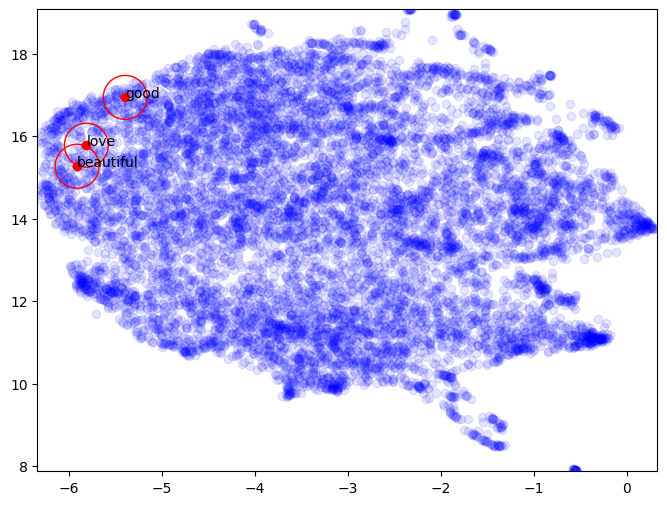

In [53]:
visualize_embeddings(reduced_embedding_umap,
                     ['good', 'love', 'beautiful'],
                     word_to_idx)

# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

https://www.codegenes.net/blog/pytorch-blstm/

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

In [ ]:
embedding = tf.keras.layers.Embedding(input_dim=vocab_size,
                                      output_dim=embedding_dimension,
                                      weights=[embedding_matrix],
                                      mask_zero=True,                   # automatically masks padding tokens
                                      name='encoder_embedding')

In [56]:
def analyze_sequence_lengths(df: pd.DataFrame, column_name='tweet'):
    """
    Analyze sequence lengths in dataset

    Args:
        df: DataFrame with text data
        column_name: Name of column containing text

    Returns:
        lengths: List of sequence lengths
        stats: Dictionary with statistics
    """
    print("\nAnalyzing sequence lengths...")

    # Calculate lengths by splitting each tweet
    lengths = [len(sentence.split()) for sentence in df[column_name].values]

    stats = {
        'min': int(np.min(lengths)),
        'max': int(np.max(lengths)),
        'mean': float(np.mean(lengths)),
        'median': float(np.median(lengths)),
        'std': float(np.std(lengths)),
        'percentile_90': int(np.percentile(lengths, 90)),
        'percentile_95': int(np.percentile(lengths, 95)),
        'percentile_99': int(np.percentile(lengths, 99)),
    }

    print("\nSequence Length Statistics:")
    print(f"  Min:    {stats['min']}")
    print(f"  Max:    {stats['max']}")
    print(f"  Mean:   {stats['mean']:.2f}")
    print(f"  Median: {stats['median']:.2f}")
    print(f"  Std:    {stats['std']:.2f}")
    print(f"  90th percentile: {stats['percentile_90']}")
    print(f"  95th percentile: {stats['percentile_95']}")
    print(f"  99th percentile: {stats['percentile_99']}")

    # Show coverage analysis
    print(f"\nCoverage analysis:")
    for percentile in [90, 95, 99]:
        max_len = int(np.percentile(lengths, percentile))
        coverage = (np.array(lengths) <= max_len).sum() / len(lengths) * 100
        print(f"  max_sequence_length={max_len:3d} covers {coverage:.1f}% of sequences")

    return lengths, stats

In [59]:
lengths, stats = analyze_sequence_lengths(train_df_en)


Analyzing sequence lengths...

Sequence Length Statistics:
  Min:    1
  Max:    62
  Mean:   25.77
  Median: 24.00
  Std:    13.93
  90th percentile: 46
  95th percentile: 49
  99th percentile: 54

Coverage analysis:
  max_sequence_length= 46 covers 90.7% of sequences
  max_sequence_length= 49 covers 95.2% of sequences
  max_sequence_length= 54 covers 99.2% of sequences


In [ ]:
class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_dim, dropout_prob):
        super(BiLSTMModel, self).__init__()
        self.bilstm = nn.LSTM(input_size, hidden_size, num_layers, bidirectional=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size * 2, output_dim)

    def forward(self, x, h0=None, c0=None):
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(
                0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(
                0), self.hidden_dim).to(x.device)

        output, (hn, cn) = self.bilstm(x, (h0, c0))
        last_output = output[-1, :, :]
        last_output = self.dropout(last_output)
        logits = self.fc(last_output)
        return logits, (hn, cn)

In [61]:
class BiLSTMModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, num_layers, output_dim, dropout_prob, freeze_embedding=False):
        super(BiLSTMModel, self).__init__()

        if not isinstance(embedding_matrix, torch.Tensor):
            embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

        self.embedding = nn.Embedding.from_pretrained(
            embeddings=embedding_matrix,
            freeze=freeze_embedding,
            padding_idx=0
        )

        # The LSTM input size is now determined by your embedding matrix's dimensions
        embedding_dim = embedding_matrix.shape[1]

        # 2. Define the BiLSTM
        # batch_first=True makes standardizing input shapes much easier: (batch, seq_len, features)
        self.bilstm = nn.LSTM(embedding_dim, hidden_size, num_layers,
                              bidirectional=True, batch_first=True, batch_first=True,
                              dropout= dropout_prob if num_layers > 1 else 0.0)

        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size * 2, output_dim)

    def forward(self, x):
        """
        x: Tensor of token ids of shape [batch_size, sequence_length]
        """
        # 1. Pass input token IDs through the embedding layer
        # Output shape: [batch_size, sequence_length, embedding_dim]
        embedded = self.embedding(x)

        # 2. Pass embeddings to BiLSTM
        # Note: PyTorch automatically initializes h0 and c0 to zeros if not provided!
        # This removes the need for your previous manual initialization.
        output, _ = self.bilstm(embedded)

        # 3. Get the last output of the sequence
        # Because we used batch_first=True, output shape is [batch_size, seq_len, hidden_size*2]
        # We grab all batches (:), the very last sequence step (-1), and all hidden features (:)
        last_output = output[:, -1, :]

        # 4. Dropout and Fully Connected
        last_output = self.dropout(last_output)
        logits = self.fc(last_output)

        return logits

# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.

## Bonus Points
Bonus points are arbitrarily assigned based on significant contributions such as:
- Outstanding error analysis
- Masterclass code organization
- Suitable extensions

**Note**: bonus points are only assigned if all task points are attributed (i.e., 6/6).

**Possible Suggestions for Bonus Points:**
- **Try other preprocessing strategies**: e.g., but not limited to, explore techniques tailored specifically for tweets or  methods that are common in social media text.
- **Experiment with other custom architectures or models from HuggingFace**
- **Explore Spanish tweets**: e.g., but not limited to, leverage multilingual models to process Spanish tweets and assess their performance compared to monolingual models.

# FAQ

Please check this frequently asked questions before contacting us

### Trainable Embeddings

You are **free** to define a trainable or non-trainable Embedding layer to load the GloVe embeddings.

### Model architecture

You **should not** change the architecture of a model (i.e., its layers).

However, you are **free** to play with their hyper-parameters.


### Neural Libraries

You are **free** to use any library of your choice to implement the networks (e.g., Keras, Tensorflow, PyTorch, JAX, etc...)

### Robust Evaluation

Each model is trained with at least 3 random seeds.

Task 5 requires you to compute the average performance over the 3 seeds and its corresponding standard deviation.

### Expected Results

Task 2 leaderboard reports around 40-50 F1-score.
However, note that they perform a hierarchical classification.

That said, results around 30-40 F1-score are **expected** given the task's complexity.

### Model Selection for Analysis

To carry out the error analysis you are **free** to either

* Pick examples or perform comparisons with an individual seed run model (e.g., Baseline seed 1337)
* Perform ensembling via, for instance, majority voting to obtain a single model.

### Error Analysis

Some topics for discussion include:
   * Precision/Recall curves.
   * Confusion matrices.
   * Specific misclassified samples.


# The End

Feel free to reach out for questions/doubts!